In [1]:
import symlib
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import os
from helpers.SimulationAnalysis import SimulationAnalysis, readHlist, a2z
import pandas as pd
from matplotlib import colormaps
import matplotlib.colors as mcolors
import scipy
import sklearn
from scipy import stats

from matplotlib.animation import FuncAnimation, PillowWriter
from PIL import Image, ImageSequence
import glob
import re

Core Question: "How is the amount of substructure in a halo related to the mass growth?"

Presumably with mass growth the amount of substructures will also grow, but we don't really know how well those are correlated.

Maybe create some kind of model that relates mass growth history with amount of substructure.

Keep track of "weird things" and parameters that are important.

Could definitely compare against WDM and SIDM in the future.

As part of the work on the project, set aside some time to read the papers you're using and try to understand them as well as you can.

In [2]:
# sim_dir is the location of a single halo. We'll talk about
# auto-generating this later, but if you downloaded "Halo933"
# in the suite "SymphonyLMC" to the directory "data/", this
# would be "data/SymphonyLMC/Halo933"

sim_dir = "D:/MWest_data/SymphonyLMC/Halo933/"
params = symlib.simulation_parameters(sim_dir)
print(params)

{'flat': True, 'H0': 70.0, 'Om0': 0.286, 'Ob0': 0.049, 'sigma8': 0.82, 'ns': 0.95, 'eps': 0.08, 'mp': 35247.6, 'h100': 0.7}


In [3]:
sim_dir1 = "D:/MWest_data/SymphonyCluster"
sim_dir2 = "D:/MWest_data/SymphonyGroup"
sim_dir3 = "D:/MWest_data/SymphonyLCluster"
sim_dir4 = "D:/MWest_data/SymphonyLMC"
sim_dir5 = "D:/MWest_data/SymphonyMilkyWay"

In [4]:
sym_cluster_halos = os.listdir(sim_dir1)
sym_group_halos = os.listdir(sim_dir2)
sym_lcluster_halos = os.listdir(sim_dir3)
sym_lmc_halos = os.listdir(sim_dir4)
sym_mw_halos = os.listdir(sim_dir5)

for i in range(len(sym_group_halos)):
    var = sym_group_halos[i]
    path = os.path.join("D:/MWest_data/SymphonyGroup", var)
    test_dir = path.replace("\\", "/")
    params = symlib.simulation_parameters(test_dir)

Example Subhalo Analysis: Plotting Postions

Our first step with analyzing any simulation data will be to look at it qualitatively. We’ll start by looking at the positions of the major Rockstar subhalos around our central halo at the last snapshot of the simulation. We will plot the central halo in one color and the subhalos in another. We’ll also need to avoid plotting any of the subhalos that were destroyed before the end of the simulation.

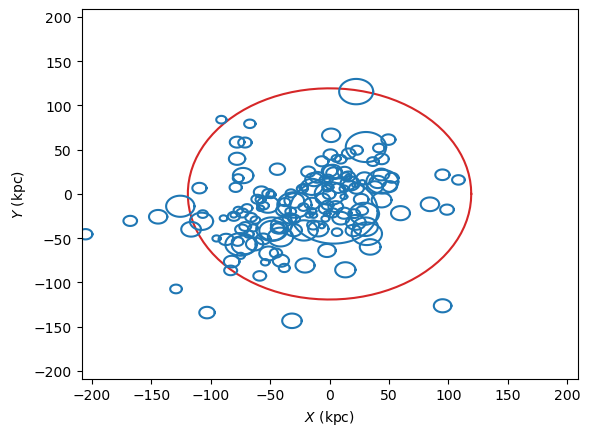

In [41]:
test_dir = "D:/MWest_data/SymphonyLMC/Halo032"

# read in sim data:
h, hist = symlib.read_subhalos(test_dir)

fig, ax = plt.subplots()

host = h[0, -1]  # first halo, last snapshot
symlib.plot_circle(ax, host["x"][0], host["x"][1], host["rvir"], c = "tab:red")

for i in range(1, len(h)):
    sub = h[i, -1]    # i-th subhalo, last snapshot
    if sub["ok"]:
        symlib.plot_circle(ax, sub['x'][0], sub['x'][1], sub['rvir'], c = "tab:blue", lw = 1.5)

# formatting code:

ax.set_xlim(-1.75*host["rvir"], 1.75*host["rvir"])
ax.set_ylim(-1.75*host["rvir"], 1.75*host["rvir"])
ax.set_xlabel(r"$X\ ({\rm kpc})$")
ax.set_ylabel(r"$Y\ ({\rm kpc})$")
plt.show()

**Example exercise**

In the histories array, there is a field called merger_snap that gives the snapshot when a subhalo first fell into the host. Try coloring subhalos that fell in from the left side of the halo (x_infall < 0) differently from ones that fell in from the right.

Example Analysis: Mass Growth

Now, we’ll try analysis that’s a bit more quantitative. We’ll look at the growth of subhalos over time: looking at the growth of the host halo and its five most massive subhalos over time. To do this, we’ll need to get the scale factors, for each snapshot with symlib.scale_factors(). We’ll also use one of the fields in histories, "merger_snap" which is the snapshot when the subhalo first fell into the host. We’ll use it to plot times before infall as dashed lines and times afterwards as solid lines.

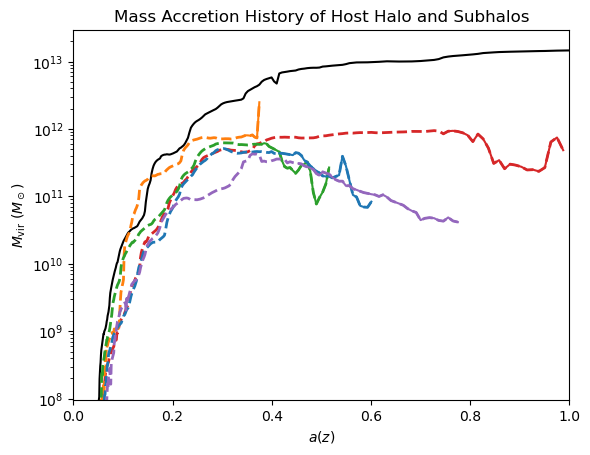

In [6]:
test_dir = "D:/MWest_data/SymphonyGroup/Halo015"

# read in sim data:
h, hist = symlib.read_subhalos(test_dir)
scale = symlib.scale_factors(test_dir)

# snapshots, for making cuts:
snaps = np.arange(len(h[0]))

fig, ax = plt.subplots()
colors = ['k', 'tab:red', 'tab:orange', 'tab:green', 'tab:blue', 'tab:purple']

for i in range(6):
    ok = h[i,:]['ok']  #snapshots where the halo exists
    if i == 0: # plot the host halo
        plt.plot(scale[ok], h[i,ok]["mvir"], c = colors[i])
    else:
        # plot the full history of the subhalo as a dashed line
        plt.plot(scale[ok], h[i,ok]['mvir'], "--", c = colors[i], lw = 2)
        # plot its history inside the host halo as a solid line
        is_sub = (snaps >= hist['merger_snap'][i]) & ok
        plt.plot(scale[is_sub], h[i, is_sub]['mvir'], c = colors[i])

# formatting code:

params = symlib.simulation_parameters("SymphonyGroup")
ax.set_xlim(0,1)
ax.set_ylim(30*params["mp"]/params["h100"], 2*h[0,-1]["mvir"])
ax.set_yscale("log")
ax.set_xlabel(r"$a(z)$")
ax.set_ylabel(r"$M_{\rm vir}\ (M_\odot)$")
ax.set_title("Mass Accretion History of Host Halo and Subhalos")
plt.show()

**Example exercise**

Try remaking this

You might have noticed that subhalos start losing mass before they actually start falling into the host (look at the transition from a dashed to solid line on the green curve in particular). Create a histogram showing r_peak/r_virial, where r_peak is the distance between the subhalo and the host halo and r_virial is the virial radius of the host halo, both calculated at the time the subhalo reaches its peak mass.

Example Analysis: The Subhalo Mass Functions

Lastly, let’s try some more rigorous statistical analysis. So far we’ve been looking at a population of subhalos surrounding one host halo. Now, we’re going to measure the subhalo mass function for all of the host halos in the Milky Way suite. The subhalo mass function is a statistic that counts the number of subhalos orbiting a host halo as a function of the subhalo’s mass. It is essentially a cumulative histogram of subhalo mass. We’ll need to look at , the average number of subhalos per host halo whose maximum mass was larger than.

In the previous exercise, we did analysis on the time when a subhalo reached its maximum mass, M_peak. We can calculate that value ourselves or use the "mpeak" field of the histories array.

More importantly, to get good statistics we’ll need to loop over all the host halos in the Milky Way suite, SymphonyMilkyWay. One way to do this would be to manually store the names of all the halo directories, but instead we’ll use library functions to do it. First, we’ll count the number of halos in the Milky Way-mass suite with symlib.n_hosts(). Then, we can get directory names symlib.get_host_directory(), which takes the base directory, suite name, and the index of the halo you want to read. Together this lets you loop over halo directories.

Constructing a mass function has a bit more code overhead than the earlier examples: the important part is how the loop over files works.

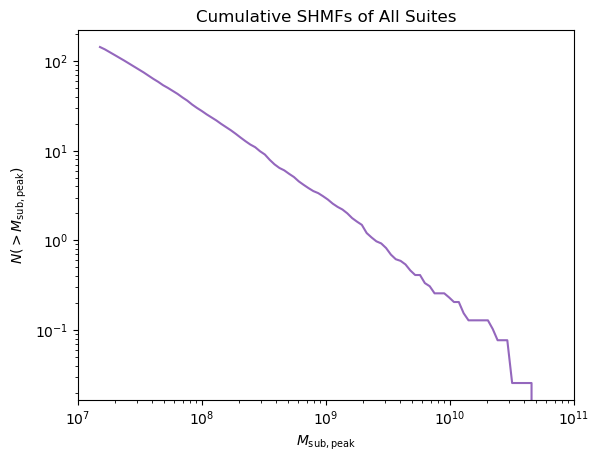

In [5]:
base_dir = "D:/MWest_data/"
suite = "SymphonyLMC"
color = "tab:purple"

fig, ax = plt.subplots()

# setting up histogram bins:
params = symlib.simulation_parameters(suite)
m_min = params["mp"]/params["h100"]*300
m_max = 1e15
n_bins = 200
bins = 10**np.linspace(np.log10(m_min), np.log10(m_max), n_bins+1)

# set up cumulative histograms for mass functions:
N_infall = np.zeros(n_bins)
N_splashback = np.zeros(n_bins)
N_vir = np.zeros(n_bins)

n_hosts = symlib.n_hosts(suite)

for halo_num in range(n_hosts):
    sim_dir = symlib.get_host_directory(base_dir, suite, halo_num)

    # read in simulation data:
    h, hist = symlib.read_subhalos(sim_dir)

    # all surviving subhalos within R_vir:
    r = np.sqrt(np.sum(h["x"][:,-1]**2, axis=1)) # z=0 distance to the host
    host_rvir = h["rvir"][0,-1]
    ok = h["ok"][:,-1] & (r < host_rvir)
    n_vir, _ = np.histogram(hist["mpeak"][ok][1:], bins=bins)

    # add to the cumulative histograms:
    N_vir += np.cumsum(n_vir[::-1])[::-1]/n_hosts

# plot:
left_bins = bins[:-1]
ax.plot(left_bins, N_vir, c = color)
    
# formatting plots:
ax.set_xlim(1e7, 1e11)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$M_{\rm sub,peak}$")
ax.set_ylabel(r"$N(>M_{\rm sub,peak})$")
ax.set_title("Cumulative SHMFs of All Suites")
plt.show()

Example exercise

You might notice that the plot above only includes subhalos with positions within the virial radius of the host halo. Try adding a curve for the mass function of surviving “splashback” subhalos, subhalos which have temporarily orbited outside of the host halo’s virial radius, to this plot.

**Recreating Fig 7 from the Symphony Paper:**

"Left panel: subhalo mass functions evaluated using virial mass at z = 0 for our five zoom-in simulation suites. Solid lines show mean
SHMFs stacked over each suite, and shaded bands show the corresponding 16th–84th percentile of the host-to-host scatter. The dotted–dashed
Group result shows the SHMF at z = 0.5, when the corresponding host halos were mass-selected in their parent box. Vertical dotted lines show
the convergence limit for each simulation, calculated as 300 times the dark matter particle mass in the highest-resolution zoom-in region, and
lines transition from solid to dashed at the median Msub/Mhost threshold corresponding to the convergence limit for each suite."

1 SymphonyLMC
2 SymphonyMilkyWay
3 SymphonyGroup
4 SymphonyLCluster
5 SymphonyCluster


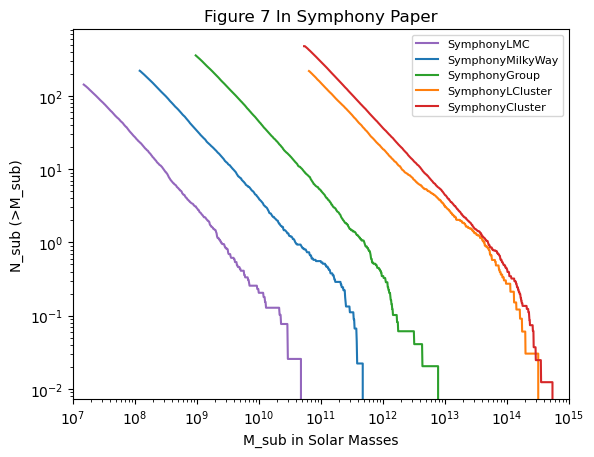

In [6]:
base_dir = "D:/MWest_data/"
suite_list = ["SymphonyLMC", "SymphonyMilkyWay", "SymphonyGroup", "SymphonyLCluster", "SymphonyCluster"]
colors = ["tab:purple", "tab:blue", "tab:green", "tab:orange", "tab:red"]

fig, ax = plt.subplots()

for index, suite in enumerate(suite_list):
    print(index + 1, suite)
    
    # setting up histogram bins:
    params = symlib.simulation_parameters(suite)
    m_min = params["mp"]/params["h100"]*300
    m_max = 1e15
    n_bins = 1000
    bins = 10**np.linspace(np.log10(m_min), np.log10(m_max), n_bins+1)

    # set up cumulative histograms for mass functions:
    N_infall = np.zeros(n_bins)
    N_splashback = np.zeros(n_bins)
    N_vir = np.zeros(n_bins)

    n_hosts = symlib.n_hosts(suite)

    for i_halo in range(n_hosts):
        sim_dir = symlib.get_host_directory(base_dir, suite, i_halo)

        # read in simulation data:
        h, hist = symlib.read_subhalos(sim_dir)

        # all surviving subhalos within R_vir:
        r = np.sqrt(np.sum(h['x'][:,-1]**2, axis = 1))
        host_rvir = h["rvir"][0,-1]
        ok = h['ok'][:,-1] & (r < host_rvir)
        n_vir, _ = np.histogram(hist["mpeak"][ok][1:], bins = bins)

        # add to the cumulative histograms:
        N_vir += np.cumsum(n_vir[::-1])[::-1]/n_hosts

    #plot
    left_bins = bins[:-1]
    ax.plot(left_bins, N_vir, c = colors[index], label = suite)
    
ax.set_xlim(1e7, 1e15)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Figure 7 In Symphony Paper")
ax.set_xlabel("M_sub in Solar Masses")
ax.set_ylabel("N_sub (>M_sub)")
ax.legend(loc = "upper right", fontsize=8)

# possibly put a cut on the distance so that only objects inside the virial radius get counted
# redo with rockstar??

**Recreating Fig 5:**

"Left panel: MAHs for the host halos in our five zoom-in simulation suites normalized to the z = 0 virial mass for each host. Solid
lines show mean MAHs for all hosts in each suite, and shaded bands show the corresponding 68% host-to-host scatter about the mean. Lines
transition to dashed at the redshift above which > 5% of the hosts in each suite are resolved with fewer than 300 particles. Jackknife resampling
of the LMC, Milky Way, and Group suites indicates that the difference between normalized MAHs is marginally significant at z & 2 and not
significant at later times; the difference between L-Cluster and Cluster MAHs is not statistically significant (see Section 3.4 for details). Dashed
(dotted–dashed) gray lines show best-fit MAHs using the Wechsler et al. (2002) exponential model and the Tasitsiomi et al. (2004) exponential
plus power-law model adopted by McBride et al. (2009b); best-fit parameters are provided in the text."

1 SymphonyLMC
2 SymphonyMilkyWay
3 SymphonyGroup
4 SymphonyLCluster
5 SymphonyCluster


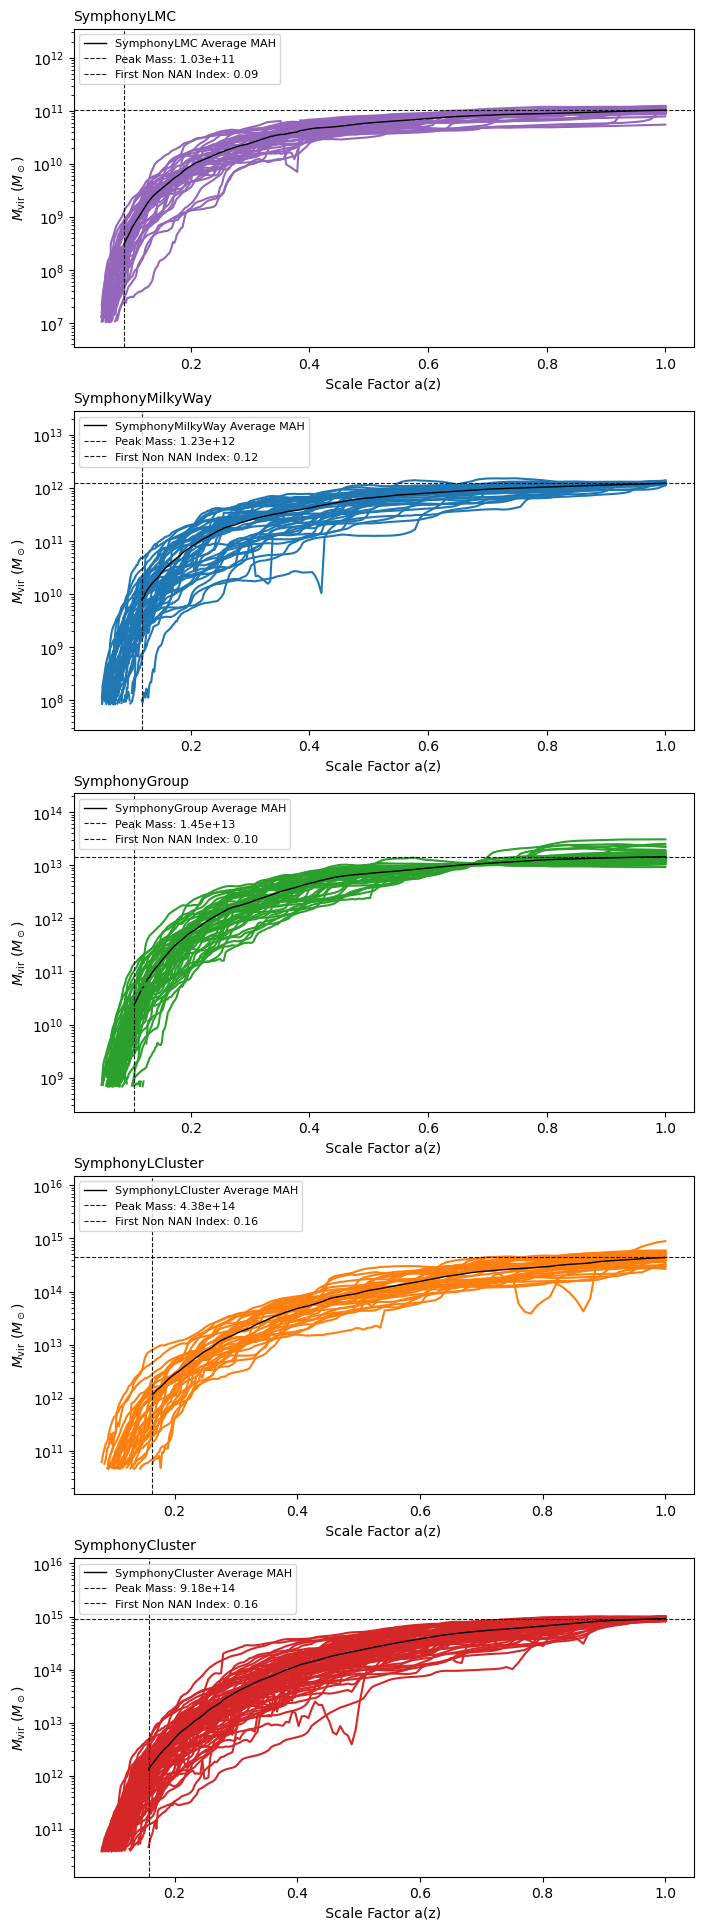

In [215]:
base_dir = "D:/MWest_data"
#suite_list = ["SymphonyLMC", "SymphonyMilkyWay"]
suite_list = ["SymphonyLMC", "SymphonyMilkyWay", "SymphonyGroup", "SymphonyLCluster", "SymphonyCluster"]

fig, ax = plt.subplots(ncols = 1, nrows = 5, figsize = (8, 24))
colors = ["tab:purple", "tab:blue", "tab:green", "tab:orange", "tab:red"]

for index, suite in enumerate(suite_list):
    print(index + 1, suite)
    
    n_hosts = symlib.n_hosts(suite)
    #n_hosts = 2

    suite_mass_list = np.zeros(n_hosts, dtype = 'object')

    for i_host in range(n_hosts):
        sim_dir = symlib.get_host_directory(base_dir, suite, i_host)
        h, hist = symlib.read_subhalos(sim_dir)
        scale_factors = symlib.scale_factors(sim_dir)

        params = symlib.simulation_parameters(sim_dir)
        particle_mass = params["mp"]
        
        host_mass = np.array(h["mvir"][0])
        num_particles = host_mass / particle_mass

        for snap_index, snap in enumerate(scale_factors):
            if num_particles[snap_index] < 300:
                host_mass[snap_index] = np.nan
        ax[index].plot(scale_factors, host_mass, color = colors[index], lw = 1.5)
        suite_mass_list[i_host] = host_mass

    avg_suite_mass = np.sum(suite_mass_list, axis = 0) / n_hosts
    ax[index].plot(scale_factors, avg_suite_mass, color = "black", lw = 1, label = f"{suite} Average MAH")

    first_non_nan_index = np.where(~np.isnan(avg_suite_mass))[0][0]
    
    #std_suite_mass = np.std(suite_mass_list, axis = 0)
    #ax[index].fill_between(scale_factors, avg_suite_mass + std_suite_mass, avg_suite_mass - std_suite_mass, color = colors[index], alpha = 0.25)

    ax[index].axhline(y = avg_suite_mass[-1], color = "black", linestyle = '--', lw = 0.8, alpha = 0.9, label = f"Peak Mass: {(avg_suite_mass[-1]):.2e}")
    ax[index].axvline(x = scale_factors[first_non_nan_index], color = "black", linestyle = '--', lw = 0.8, alpha = 0.9, label = f"First Non NAN Index: {scale_factors[first_non_nan_index]:.2f}")
    ax[index].set_yscale("log")
    ax[index].set_xlabel(r" Scale Factor a(z) ", fontsize = 10)
    ax[index].set_ylabel(r"$M_{\rm vir}\ (M_\odot)$", fontsize = 10)
    ax[index].set_ylim(1e2 * particle_mass, 1e8 * particle_mass)
    ax[index].legend(loc = 'upper left', fontsize = 8)
    ax[index].set_title(suite, loc = "left", fontsize = 10)
    
#fig.suptitle("Total and Average Mass Accretion Histories Of All Suites", fontsize = 13, y = 0.95)
plt.show()

In [ ]:
base_dir = "D:/MWest_data"
suite_list = ["SymphonyLCluster", "SymphonyCluster", "SymphonyLMC", "SymphonyGroup", "SymphonyMilkyWay"]


def fig_5_gen_avg_lines(base_dir, suite_list):
    
    # create a figure to be modified later + colors
    fig, ax = plt.subplots()
    colors = ["tab:orange", "tab:red", "tab:purple", "tab:green", "tab:blue"]


    # for each suite in the suite_list:
    for suite in range(len(suite_list)):
        print(suite+1, suite_list[suite])

    # assign n_hosts the value of the number of hosts in the suite
        n_hosts = symlib.n_hosts(suite_list[suite])
        print("the suite has", n_hosts, "halos in it")
        scale_factors = symlib.scale_factors(sim_dir)
        test_scale_factors = scale_factors[:4]

    # for each host in the suite, get the directory and read in the data

        tot_suite_mass_at_snap = 0
        tot_suite_mass = np.zeros(4)
        #tot_suite_mass = np.zeros(len(scale_factors))
        avg_suite_mass = np.zeros(4)
        #avg_suite_mass = np.zeros(len(scale_factors))

    # for each host in the suite:
        for ith_host in range(n_hosts):
            sim_dir = symlib.get_host_directory(base_dir, suite_list[suite], ith_host)
            s, hist = symlib.read_rockstar(sim_dir)          # read in simulation data

            n_snaps = len(scale_factors)                     # creates a variable of equal length to the number of entries in scale_factors
            test_snaps = len(test_scale_factors)

            tot_mass_at_snap = 0
            tot_halo_mass = np.zeros(4)
            #tot_halo_mass = np.zeros(len(scale_factors))
            avg_halo_mass = np.zeros(4)
            #avg_halo_mass = np.zeros(len(scale_factors))

    # for each snapshot corresponding to a value in scale_factors (time):
            for snap in range(test_snaps):
                total_mass = 0
                valid_count = 0
                mass = s[1, snap]["m"]                     # gives the virial mass of the 1st most massive halo (host halo) at that snapshot
                tot_halo_mass[snap] += mass                # add the mass at the current snapshot to the total mass

#ax.plot(scale_factors, avg_suite_mass, label = suite_list[suite], lw = 1.25, color = colors[suite])

            
        
# Some plotting code to make things look nice.
param = symlib.simulation_parameters(suite_list[suite])
ax.set_xlim(0, 1)


In [89]:
base_dir = "D:/MWest_data"
suite_list = ["SymphonyCluster", "SymphonyLCluster", "SymphonyGroup", "SymphonyMilkyWay", "SymphonyLMC"]

def fig_5_gen_avg_lines(base_dir, suite_list):

# create a figure to be modified later + colors
    fig, ax = plt.subplots(1, 2, figsize = (12,5))
    colors = ["tab:red", "tab:orange", "tab:green", "tab:blue", "tab:purple"]

# for each suite, get the number of hosts in the suite and prepare an empty list for the data
    for suite in range(len(suite_list)):
        total_hosts = symlib.n_hosts(suite_list[suite])
        host_data = []

        print(suite_list[suite], total_hosts)

# for each host in the suite, get the directory, read in the data and scale factors, calculate redshifts for later
        for j in range(total_hosts):
            sim_dir = symlib.get_host_directory(base_dir, suite_list[suite], j)
            r, _ = symlib.read_rockstar(sim_dir)
            scale_factors = symlib.scale_factors(sim_dir)
            redshifts = (1/scale_factors)-1
            n_snaps = len(scale_factors)
            host_data.append(r[0])  # host only

            average_masses = []
            normalized_average_masses = []

            progress = round(j/total_hosts, 2) * 100
            print(sim_dir, f"{progress:.2f} % \r", end="", flush=True)
        
            for snap in range(n_snaps):
                total_mass = 0
                valid_count = 0

                for r_host in host_data:
                    m = r_host[snap]['m']
                    ok = r_host[snap]["ok"]
                    if ok:
                        total_mass += m
                        valid_count += 1

                if valid_count > 0:
                    average_masses.append(total_mass / valid_count)
                    normalized_average_masses.append(total_mass / r_host[199]['m'])
                else:
                    average_masses.append(np.nan)
                    normalized_average_masses.append(np.nan)
                
        ax[1].plot(redshifts, average_masses, label = suite_list[suite], color = colors[suite])
        ax[0].plot(redshifts, normalized_average_masses, label = suite_list[suite], color = colors[suite])
    
    param = symlib.simulation_parameters(suite_list[suite])
    ax[0].invert_xaxis()
    ax[0].set_yscale("log")
    ax[0].set_xlabel(r"Redshift z")
    ax[0].set_ylabel(r"$M_{\rm vir}\ (M_\odot)$")
    ax[0].set_title(r"Normalized Average Masses vs Redshift For All Suites")
    ax[0].legend(loc = "upper left", fontsize = 6.5)

    ax[1].invert_xaxis()
    ax[1].set_yscale("log")
    ax[1].set_xlabel(r"Redshift z")
    ax[1].set_ylabel(r"$M_{\rm vir}\ (M_\odot)$")
    ax[1].set_title(r"Average Masses vs Redshift For All Suites")
    ax[1].legend(loc = "upper left", fontsize = 6.5)
    plt.show()

# could try taking log of scale factors and then do the transformation + x axis flip
# turn all the stuff we're doing into functions for later + making toggleable function values to allow us to not average every time
# turn off redshift, not plotting, etc.

SymphonyCluster 81
SymphonyLCluster 33onyCluster\Halo734 99.00 % 
SymphonyGroup 49mphonyLCluster\Halo_050 97.00 % 
SymphonyMilkyWay 45onyGroup\Halo985 98.00 % 
SymphonyLMC 39SymphonyMilkyWay\Halo990 98.00 %  
D:/MWest_data\SymphonyLMC\Halo933 97.00 %  

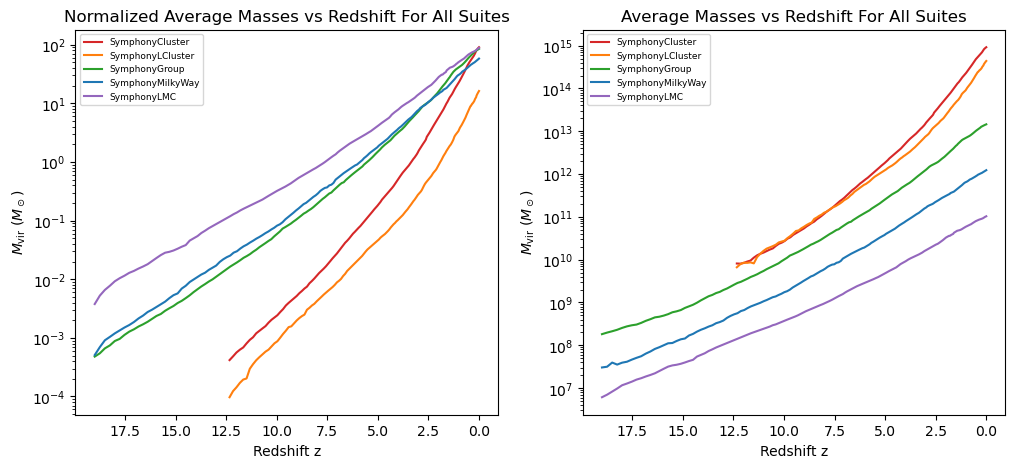

In [90]:
fig_5_gen_avg_lines(base_dir, suite_list)

**Week 3 (7/14):**

Repeat SHMF measurement at redshift 0.1, 0.2, 0.5, 1, 2. Plot each result separately in the style of Symphony Figure 6.

**Week 4 (7/21):**

Write script to automate SHMF measurement at any redshift. Test that it reproduces your Week 3 results.
Use script to measure total subhalo abundance, N_sub,tot, as a function of redshift. This can be for a single host.


In [20]:
import math
import matplotlib.cm as cm
import matplotlib.colors as mcolors

base_dir = "D:/MWest_data"
suite_list = ["SymphonyLMC", "SymphonyMilkyWay", "SymphonyGroup", "SymphonyLCluster", "SymphonyCluster"]
redshifts = [0.1, 0.2, 0.5, 1.0, 2.0]

def shmf_any_redshifts(base_dir, suite_list, redshifts):

    og_colors = ["tab:purple", "tab:blue", "tab:green", "tab:orange", "tab:red"]

    # figure setup
    n_cols = 3
    n_rows = math.ceil(len(redshifts) / n_cols) 
    fig, axs = plt.subplots(n_rows, n_cols, figsize = (5 * n_cols, 4 * n_rows), sharex = True, sharey = True)
    axs = axs.flatten()


# for each redshift in the list of target redshifts
    for z_index, target_z in enumerate(redshifts):
        ax = axs[z_index]

        # for each suite in the list of suites
        for suite_index, suite_name in enumerate(suite_list):

            # create histogram bins
            params = symlib.simulation_parameters(suite_name)
            m_min = params["mp"]/params["h100"]*300
            m_max = 1e14
            n_bins = 300
            bins = 10**np.linspace(np.log10(m_min), np.log10(m_max), n_bins + 1)
            left_bins = bins[:-1]

            n_hosts = symlib.n_hosts(suite_name)        # get number of hosts
        
            test = np.zeros(n_bins)
    
            # get starting color for each suite:
            start_color = mcolors.to_rgb(og_colors[suite_index])
        
            red = start_color[0]
            green = start_color[1]
            blue = start_color[2]
            new_red = max(0, min(red + (z_index * 0.05), 1.0))        # Increase red channel
            new_green = max(0, min(green - (z_index * 0.01), 1.0))   # Decrease green channel
            new_blue = max(0, min(blue - (z_index * 0.01), 1.0))     #  Decrease blue channel
        
            color = (new_red, new_green, new_blue)

            # for each subhalo in the suite
            for i_host in range(n_hosts):
                sim_dir = symlib.get_host_directory(base_dir, suite_name, i_host)        # get directory to host

                #print(target_z, suite_name, sim_dir)

                scale_factors = symlib.scale_factors(sim_dir)      # read in scale factors list
                target_a = 1 / (1 + target_z)                    # convert from target redshift to corresponding scale factor or snapshot
                snap_index = np.argmin(np.abs(scale_factors - target_a))   # round to closest snapshot

                h, hist = symlib.read_subhalos(sim_dir)  # read in data

                # figure out which subhalos exist within the virial radius of the host halo at a given snapshot
                r = np.sqrt(np.sum(h["x"][:, snap_index]**2, axis = 1))   # calculate the subhalo's distance
                host_rvir = h["rvir"][0, snap_index]                      # get the virial radius of the host halo
                ok = h["ok"][:, snap_index] & (r < host_rvir)             # only keep the halo if it's been okayed and inside the virial radius
                n_vir, _ = np.histogram(hist["mpeak"][ok][1:], bins = bins)      # add to histogram
                N_vir = np.cumsum(n_vir[::-1])[::-1]

                test += N_vir

            #print(i_host, n_hosts)

                if i_host == n_hosts-1:

                    label = suite_name
            
                    axs[z_index].plot(left_bins, test / n_hosts, color = color, lw = 1.0, label = label)
            
                    axs[z_index].set_xlim(1e6, 1e15)
                    axs[z_index].set_ylim(1e0, 1e3)
                    axs[z_index].set_xscale("log")
                    axs[z_index].set_yscale("log")
                    axs[z_index].set_title(f"SHMF Of All Suites At z = {target_z}")
                    axs[z_index].set_xlabel("Msub [M☉])")
                    axs[z_index].set_ylabel("# of subhalos (>M)")

                    # global title
                    handles, labels = axs[0].get_legend_handles_labels()
                    fig.legend(handles, labels, loc = (0.15, 0.95), ncol = len(suite_list), fontsize = 10)

    # remove unused axes
    for i in range(len(redshifts), len(axs)):
        fig.delaxes(axs[i])

    plt.show()

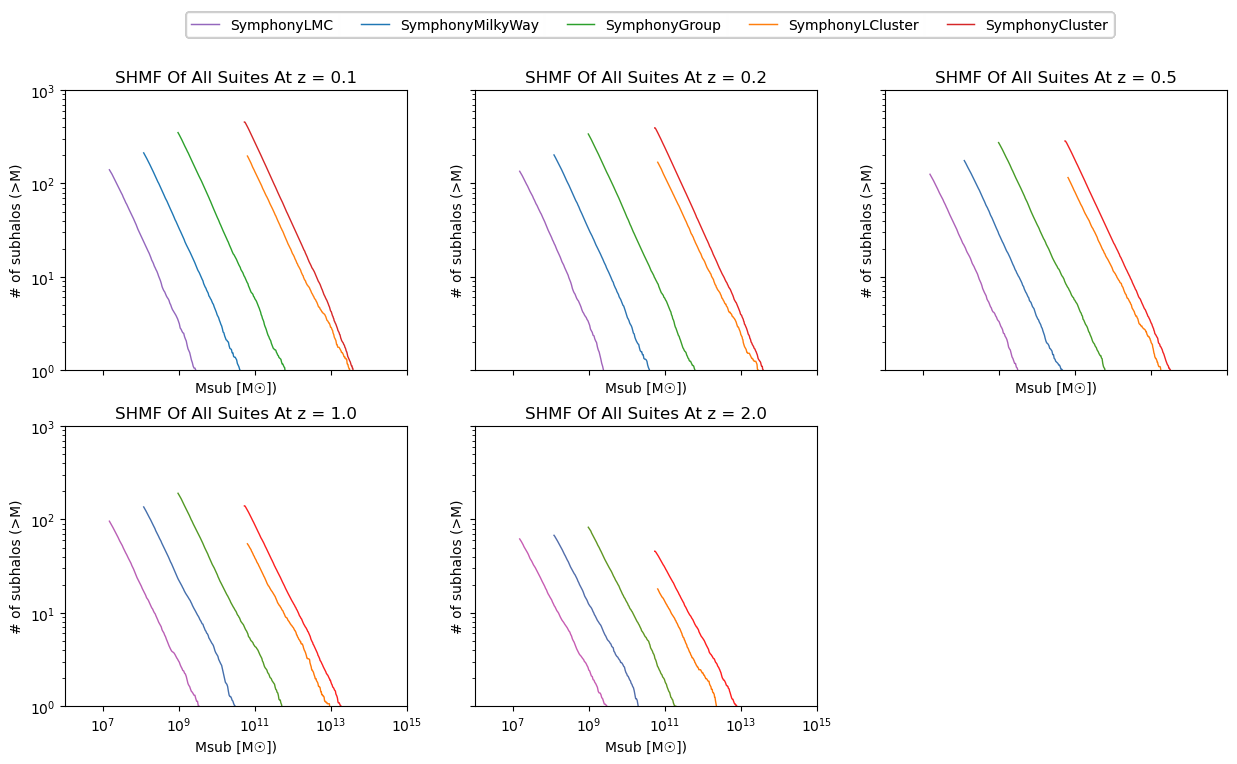

In [21]:
shmf_any_redshifts(base_dir, suite_list, redshifts)

**Week 4 (7/21):**

Write script to automate SHMF measurement at any redshift. Test that it reproduces your Week 3 results. Use script to measure total subhalo abundance, N_sub,tot, as a function of redshift. This can be for a single host.

In [2]:
base_dir = "D:/MWest_data"
suite_list = ["SymphonyLMC", "SymphonyMilkyWay", "SymphonyGroup", "SymphonyLCluster", "SymphonyCluster"]
redshifts = [0.1, 0.2, 0.5, 1.0, 2.0]
og_colors = ["tab:purple", "tab:blue", "tab:green", "tab:orange", "tab:red"]

def nsub_vs_z(base_dir, suite_list, redshifts, og_colors):
    # figure setup
    fig, ax = plt.subplots(2, 3, figsize = (12, 10))
    ax = ax.flatten()

    # for each suite in the list of suites
    for suite_index, suite_name in enumerate(suite_list):
    
        params = symlib.simulation_parameters(suite_name)
        m_min = params["mp"]/params["h100"]*300
        m_max = 1e14
        n_bins = 1000
        bins = 10**np.linspace(np.log10(m_min), np.log10(m_max), n_bins + 1)
        h100 = params["h100"]
        n_hosts = symlib.n_hosts(suite_name)        # get number of hosts

        num_halos = np.zeros(len(redshifts))
        normalized_num_halos = np.zeros(len(num_halos))
        
        # for each subhalo in the suite
        for i_host in range(n_hosts):
            sim_dir = symlib.get_host_directory(base_dir, suite_name, i_host)        # get directory to host
            scale_factors = symlib.scale_factors(sim_dir)      # read in scale factors list
            h, hist = symlib.read_subhalos(sim_dir)  # read in data

            #print(sim_dir)

            for i_z, target_z in enumerate(redshifts):
                target_a = 1 / (1 + target_z)                    # convert from target redshift to corresponding scale factor or snapshot
                snap_index = np.argmin(np.abs(scale_factors - target_a))   # round to closest snapshot

                # filter out subhalos that aren't the host, are within the virial radius, and are still alive at the snapshot
                r = np.sqrt(np.sum(h["x"][:, snap_index]**2, axis = 1))   # calculate the subhalo's distance
                host_rvir = h["rvir"][0, snap_index]                      # get the virial radius of the host halo
                ok = h["ok"][:, snap_index] & (r < host_rvir) # only keep the halo if it's been okayed and a subhalo inside the virial radius

                # count # of subhalos inside host_rvir
                n_vir, _ = np.histogram(hist["mpeak"][ok][1:], bins = bins)
                
                num_halos[i_z] += np.sum(n_vir)

            normalized_num_halos = num_halos / num_halos[0]
                
            #num_halos /= n_hosts
            
            ax[suite_index].plot(redshifts, normalized_num_halos, color = og_colors[suite_index], lw = 1.0, label = suite_name)
        
        ax[suite_index].invert_xaxis()
        ax[suite_index].set_xlabel("Redshift (z)")
        ax[suite_index].set_ylabel("# of Subhalos")
        ax[suite_index].set_title(suite_name)

    # remove unused axes
    for i in range(len(redshifts), len(ax)):
        fig.delaxes(ax[i])

    fig.suptitle("Normalized # of Subhalos vs Redshift z For All Hosts In Each Suite", fontsize = 15)
    plt.tight_layout(rect = [0, 0.3, 1, 0.95])
    plt.show()

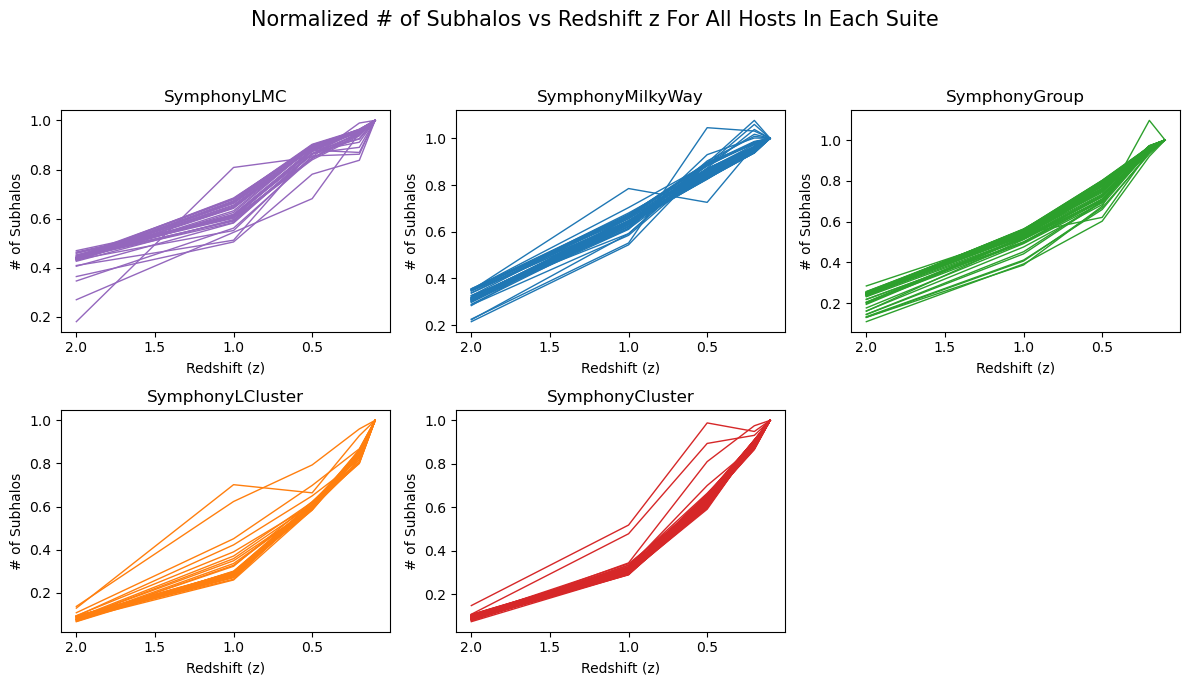

In [3]:
nsub_vs_z(base_dir, suite_list, redshifts, og_colors)

In [5]:
base_dir = "D:/MWest_data"
suite_list = ["SymphonyLMC", "SymphonyLCluster"]
#suite_list = ["SymphonyLMC", "SymphonyMilkyWay", "SymphonyGroup", "SymphonyLCluster", "SymphonyCluster"]
redshifts = [0.1, 0.2, 0.5, 1.0, 2.0]
og_colors = ["tab:purple", "tab:blue", "tab:green", "tab:orange", "tab:red"]

def total_mass_vs_z(base_dir, suite_list, redshifts, og_colors):
    # figure setup
    fig, ax = plt.subplots(2, 3, figsize = (12, 10))
    ax = ax.flatten()

    # for each suite in the list of suites
    for suite_index, suite_name in enumerate(suite_list):
    
        params = symlib.simulation_parameters(suite_name)
        h100 = params["h100"]
    
        n_hosts = symlib.n_hosts(suite_name)        # get number of hosts

        total_mass = np.zeros(len(redshifts))
        normalized_total_mass = np.zeros(len(total_mass))
        
        # for each subhalo in the suite
        for i_host in range(n_hosts):
            sim_dir = symlib.get_host_directory(base_dir, suite_name, i_host)        # get directory to host
            scale_factors = symlib.scale_factors(sim_dir)      # read in scale factors list

            h, hist = symlib.read_subhalos(sim_dir)  # read in data

            #print(sim_dir)

            for i_z, target_z in enumerate(redshifts):
                target_a = 1 / (1 + target_z)                    # convert from target redshift to corresponding scale factor or snapshot
                snap_index = np.argmin(np.abs(scale_factors - target_a))   # round to closest snapshot
                
                host_mass = h["mvir"][0, snap_index]
                z0_mass = h["mvir"][0, -1]

                # filter out subhalos that aren't the host, are within the virial radius, and are still alive at the snapshot
                r = np.sqrt(np.sum(h["x"][:, snap_index]**2, axis = 1))   # calculate the subhalo's distance
                host_rvir = h["rvir"][0, snap_index]                      # get the virial radius of the host halo
                ok = h["ok"][:, snap_index] & (r < host_rvir)      # only keep the halo if it's been okayed at the current snapshot

                msun_mass = host_mass / h100    # host and subhalo mass, converted into solar masses

                total_mass[i_z] += msun_mass

                normalized_total_mass[i_z] = host_mass / z0_mass

            total_mass /= n_hosts
    
            ax[suite_index].plot(redshifts, normalized_total_mass, color = og_colors[suite_index], lw = 1.0, label = suite_name)
        
        
        ax[suite_index].invert_xaxis()
        ax[suite_index].set_xlabel("Redshift (z)")
        ax[suite_index].set_ylabel("Total Mass [M☉])")
        ax[suite_index].set_title(suite_name)

    # remove unused axes
    for i in range(len(redshifts), len(ax)):
        fig.delaxes(ax[i])

    fig.suptitle("Normalized Total Mass vs Redshift z For All Hosts In Each Suite", fontsize = 15)
    plt.tight_layout(rect = [0, 0.3, 1, 0.95])
    plt.show()

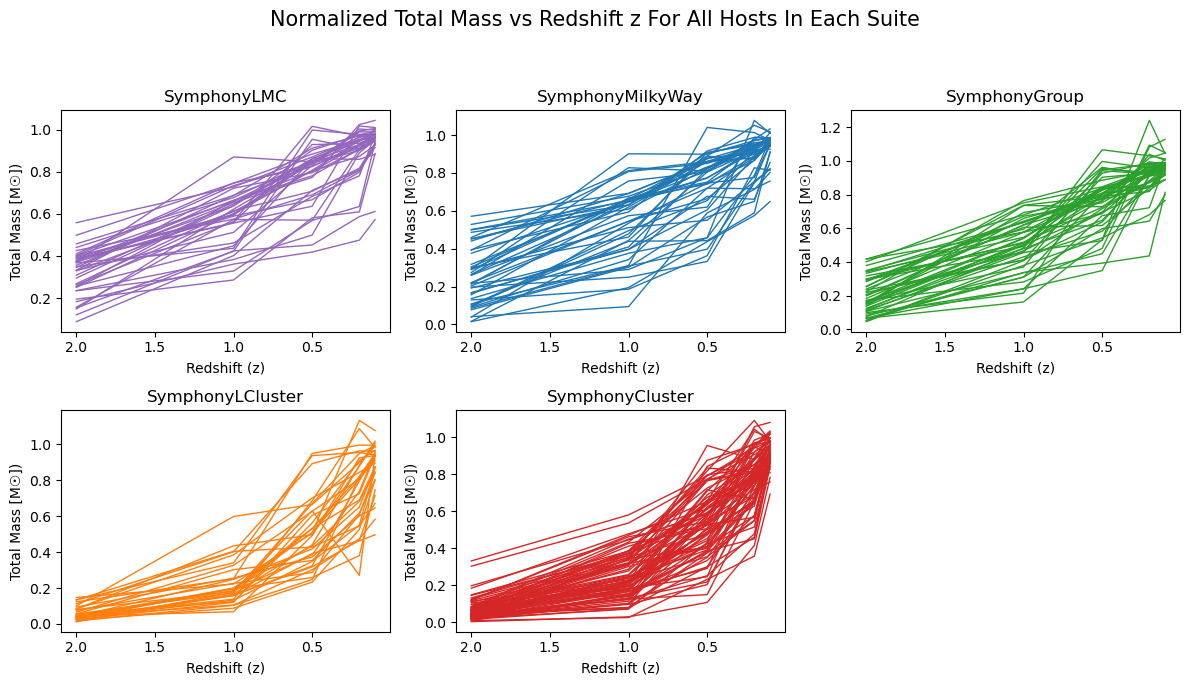

In [9]:
total_mass_vs_z(base_dir, suite_list, redshifts, og_colors)

Trying to combine the two plots:

In [7]:
from scipy.optimize import curve_fit
e = np.exp(1)

def exponentialfit(x, a, b):
        return (a * e**(-1 * b * x))

In [8]:
def linearcorrection(x, beta, gamma):
    return (((1 + x) ** beta) * (e ** (-1 * gamma * x)))

1 SymphonyLMC 39
2 SymphonyMilkyWay 45
3 SymphonyGroup 49
4 SymphonyLCluster 33
5 SymphonyCluster 81


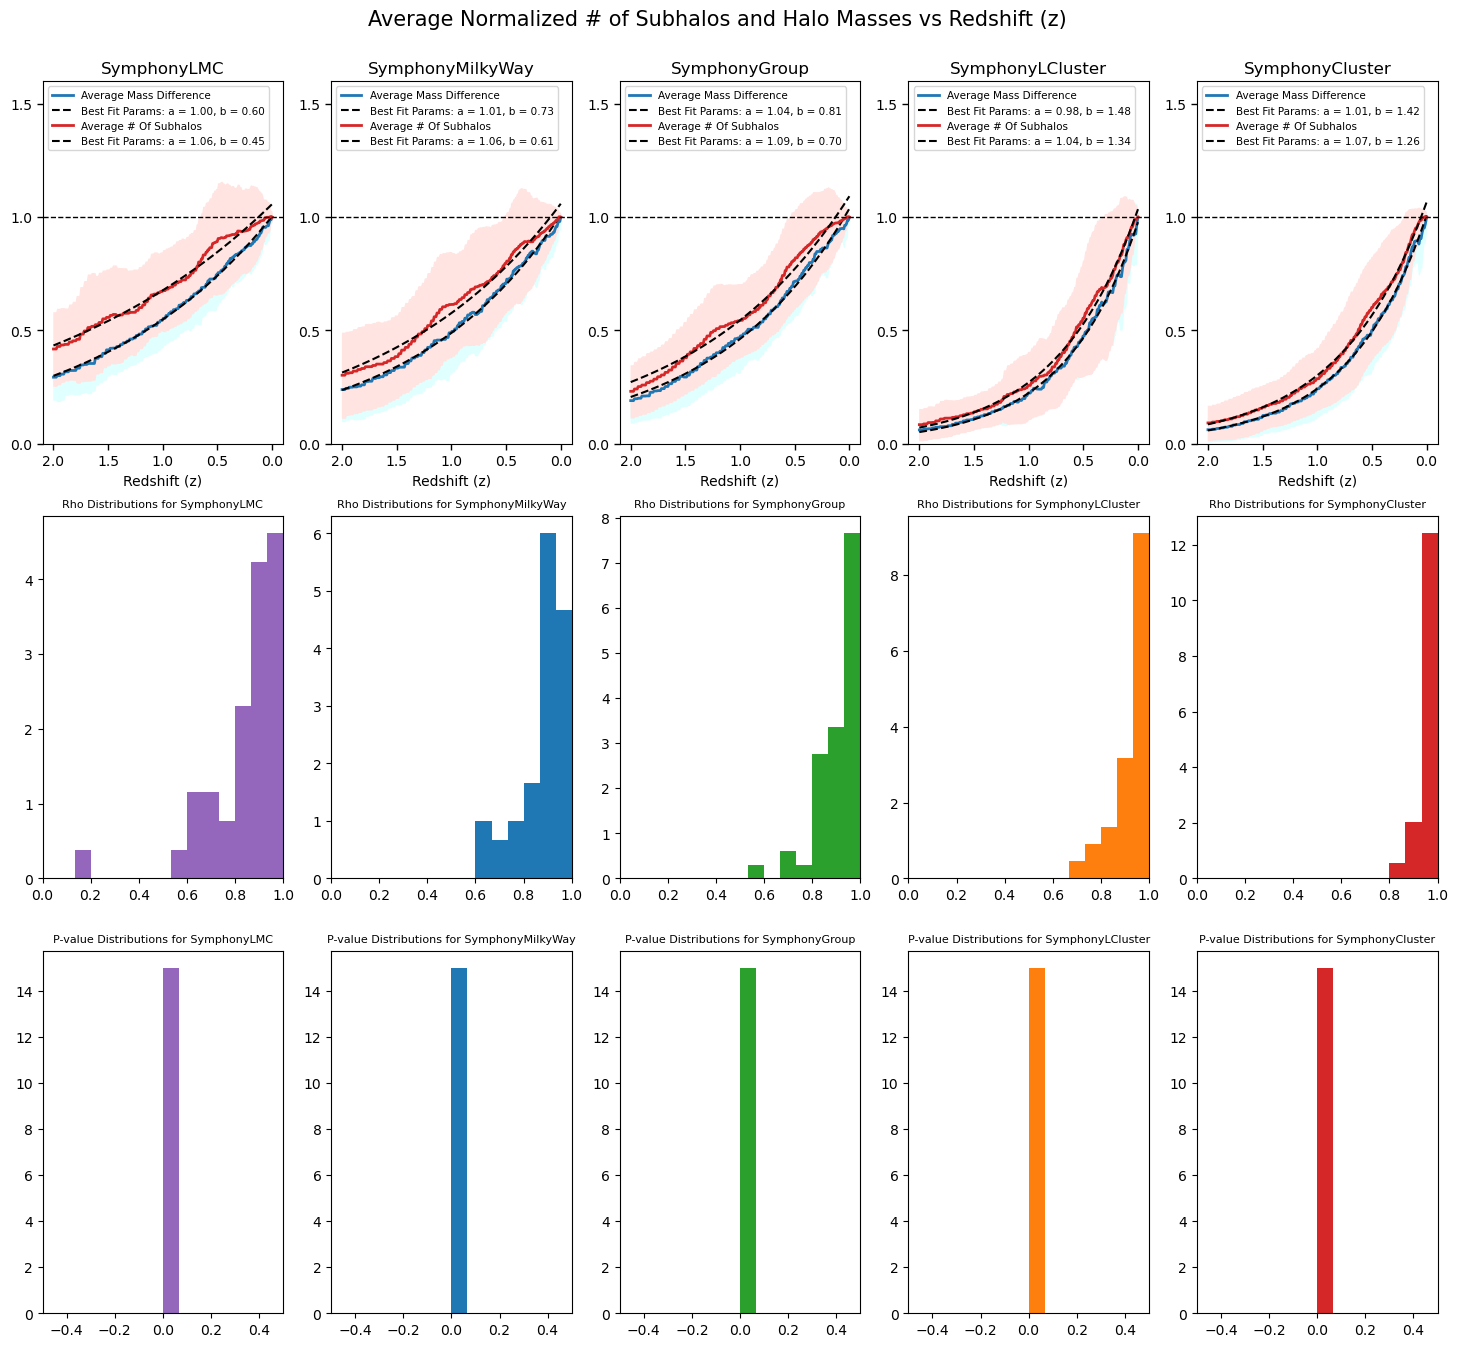

In [32]:
base_dir = "D:/MWest_data"
#suite_list = ["SymphonyLMC"]
suite_list = ["SymphonyLMC", "SymphonyMilkyWay", "SymphonyGroup", "SymphonyLCluster", "SymphonyCluster"]
og_colors = ["tab:purple", "tab:blue", "tab:green", "tab:orange", "tab:red"]

# figure setup
fig, axs = plt.subplots(ncols = 5, nrows = 3, figsize = (18, 16))

rho_all_suites = np.zeros(5, dtype = 'object')
p_all_suites = np.zeros(5, dtype = 'object')

# first, for a particular suite in suite_list, let's get the average mass and average # of subhalos as a function of z:
for index, suite in enumerate(suite_list):

    # get parameters for making histograms, as before:
    params = symlib.simulation_parameters(suite)
    m_min = params["mp"]/params["h100"]*300
    m_max = 1e15
    n_bins = 1000
    bins = 10**np.linspace(np.log10(m_min), np.log10(m_max), n_bins + 1)
    h100 = params["h100"]
    left_bins = bins[:-1]

    n_hosts = symlib.n_hosts(suite)  # get the number of hosts in the suite
    print(index + 1, suite, n_hosts)

    suite_norm_mass_diffs = []
    suite_norm_num_nsubs = []

    rho_suite = []
    p_suite = []

    # read in sim data for every host in the suite
    for i_host in range(n_hosts):
        sim_dir = symlib.get_host_directory(base_dir, suite, i_host)        # get directory to host
        scale_factors = symlib.scale_factors(sim_dir)                            # read in scale factors list
        h, hist = symlib.read_subhalos(sim_dir)                                  # read in data

        redshifts = np.linspace(2, 0, len(scale_factors))     # array from 0 to 2 with a number of elements equal to the number of snapshots; this should allow for the loop to iterate over every snapshot
        mass_diffs = np.zeros(len(scale_factors))
        num_subhalos = np.zeros(len(scale_factors))

        for i_z, target_z in enumerate(redshifts):
            # looking at masses first:
            target_a = 1 / (1 + target_z)                                         # convert from target redshift to corresponding scale factor or snapshot
            snap_index = np.argmin(np.abs(scale_factors - target_a))              # round to closest snapshot
            end_snap = np.argmin(np.abs(scale_factors - (1/(1+redshifts[-1]))))   # get the snapshot corresponding to the lowest redshift

            # get host mass, position, virial radius
            host_rvir = h["rvir"][0, snap_index]   # assumed to be (0, 0, 0) for all snaps
            host_pos = h["x"][0, snap_index]
            host_mass = h["mvir"][0, snap_index]

            # filter out subhalos that aren't the host and are still alive at the snapshot
            sub_rvir = h["rvir"][1:, snap_index]
            sub_pos = h["x"][1:, snap_index]
            
            ok1 = h["ok"][1:, snap_index]
            ok_sub_pos = sub_pos[ok1]
            ok_sub_rvir = sub_rvir[ok1]
            ok_sub_mass = h["mvir"][1:, snap_index][ok1]

            dist = np.sqrt(np.sum(ok_sub_pos**2, axis=1))

            arr_host_rvir = host_rvir * np.ones(len(dist))
            #print(len(dist), len(ok_sub_rvir), len(arr_host_rvir))

            sub_exists_inside_hostrvir = (dist < arr_host_rvir - ok_sub_rvir)
            arr_valid_sub_masses = np.zeros(len(sub_exists_inside_hostrvir))

            num_subhalos[i_z] = sum(sub_exists_inside_hostrvir)

            # now looking at # of subhalos; count total number of subhalos inside host_rvir
            #n_vir, _ = np.histogram(hist["mpeak"][ok2], bins = bins)      # gets the number of okayed subhalos at a particular snapshot
            #num_subhalos[i_z] = np.sum(n_vir)

            for sub_index, sub_TF in enumerate(sub_exists_inside_hostrvir):
                if sub_TF == True:
                    arr_valid_sub_masses[sub_index] = ok_sub_mass[sub_index]
                    
            #print(arr_valid_sub_masses, len(arr_valid_sub_masses))
            
            tot_subhalo_mass_at_z = np.sum(arr_valid_sub_masses, axis = 0)
            mass_diff = (host_mass - tot_subhalo_mass_at_z)                    # calculates the difference in mass between the host and the sum of the subhalo masses
            mass_diffs[i_z] = mass_diff

        z0_virial_mass = h["mvir"][0][-1]
        z0_tot_subs_mass = tot_subhalo_mass_at_z
        z0_mass_diff = z0_virial_mass - z0_tot_subs_mass
        z0_num_nsubs = num_subhalos[-1]

        norm_mass_diffs = mass_diffs / z0_mass_diff
        suite_norm_mass_diffs.append(norm_mass_diffs)

        norm_num_nsubs = num_subhalos / z0_num_nsubs
        suite_norm_num_nsubs.append(norm_num_nsubs)

        #axs[index].plot(redshifts, norm_mass_diffs, color = "tab:blue", lw = 1)  <-- plotting every host
        #axs[index].plot(redshifts, norm_num_nsubs, color = "tab:red", lw = 1)    <-- plotting every host

        rho, p = scipy.stats.spearmanr((norm_mass_diffs / np.max(norm_mass_diffs)), (norm_num_nsubs / np.max(norm_num_nsubs)))
        rho_suite.append(rho)
        p_suite.append(p)

    #print(suite, rho_suite)
    rho_all_suites[index] = rho_suite
    p_all_suites[index] = p_suite

    avg_norm_mass_diffs = np.array([sum(masses) for masses in zip(*suite_norm_mass_diffs)]) / n_hosts
    avg_norm_num_nsubs = np.array([sum(nsubs) for nsubs in zip(*suite_norm_num_nsubs)]) / n_hosts

    std_normalized_masses = np.std(suite_norm_mass_diffs, axis = 0)
    std_normalized_nsubs = np.std(suite_norm_num_nsubs, axis = 0)

    # calculate the best fit parameters for the mass curve using an exponential fit
    best_fit_params1 = curve_fit(exponentialfit, redshifts, avg_norm_mass_diffs)
    best_fit_params2 = curve_fit(exponentialfit, redshifts, avg_norm_num_nsubs)

    
    # plotting rho and p-value distributions
    axs[1, index].hist(rho_suite, bins = 15, range = (0, 1), color = og_colors[index], density = True)
    axs[1, index].set_xlim(0, 1)
    axs[1, index].set_title(f"Rho Distributions for {suite}", fontsize = 8)

    axs[2, index].hist(p_suite, 15, range = (0, 1), color = og_colors[index], density = True)
    axs[2, index].set_xlim(-0.5, 0.5)
    axs[2, index].set_title(f"P-value Distributions for {suite}", fontsize = 8)

    # plotting curves
    axs[0, index].plot(redshifts, avg_norm_mass_diffs, color = "tab:blue", lw = 2, label = "Average Mass Difference")
    axs[0, index].fill_between(redshifts, avg_norm_mass_diffs + std_normalized_masses, avg_norm_mass_diffs - std_normalized_masses, color = "lightcyan")
    axs[0, index].plot(redshifts, (best_fit_params1[0][0] * e ** (-1 * best_fit_params1[0][1] * redshifts)), color = "black",
                    linestyle = "--", label = f"Best Fit Params: a = {best_fit_params1[0][0]:.2f}, b = {best_fit_params1[0][1]:.2f}")
    
    axs[0, index].plot(redshifts, avg_norm_num_nsubs, color = "tab:red", lw = 2, label = "Average # Of Subhalos")
    axs[0, index].fill_between(redshifts, avg_norm_num_nsubs + std_normalized_nsubs, avg_norm_num_nsubs - std_normalized_nsubs, color = "mistyrose")
    axs[0, index].plot(redshifts, (best_fit_params2[0][0] * e ** (-1 * best_fit_params2[0][1] * redshifts)), color = "black",
                    linestyle = "--", label = f"Best Fit Params: a = {best_fit_params2[0][0]:.2f}, b = {best_fit_params2[0][1]:.2f}")
    
    axs[0, index].invert_xaxis()
    axs[0, index].set_xlabel("Redshift (z)")
    axs[0, index].set_ylim(0.0, 1.6)
    axs[0, index].axhline(y = 1, color = "black", lw = 1, linestyle = "--")
    axs[0, index].locator_params(axis = "x", nbins = 5)
    axs[0, index].locator_params(axis = "y", nbins = 5)
    axs[0, index].tick_params(axis = "both",  which = "major", length = 4, width = 1, direction = "out")

    axs[0, index].legend(fontsize = 7.5, loc = "upper left")
    axs[0, index].set_title(suite)

fig.suptitle("Average Normalized # of Subhalos and Halo Masses vs Redshift (z)", fontsize = 15, y = 0.925)
plt.show()

# do the 2-sample KS test for the spearman rho and p values (completed!!)
# look at p-values and try to resolve the question regarding the delta-function-like behavior
# upgrade the distance calculation and factor in the possibility of there being subhalos that are partially inside the host halo, especially at high redshift
# turn things into functions for ease of use!

In [33]:
n_hosts_all_suites = []
suite_list = ["SymphonyLMC", "SymphonyMilkyWay", "SymphonyGroup", "SymphonyLCluster", "SymphonyCluster"]
for suite in suite_list:
    n_hosts = symlib.n_hosts(suite)
    n_hosts_all_suites.append(n_hosts)
print(n_hosts_all_suites)

[39, 45, 49, 33, 81]


In [37]:
# calculating the average KS metric:
from itertools import combinations
c_alpha = 1.358        # for an alpha of 0.05, the coefficient value is 1.358
ks_metrics_all = []

def ks_metric_calc(c_alpha, n, m):
    ks_metric = c_alpha * np.sqrt((n+m)/(n*m))
    return ks_metric

r = 2
combo_iterator = combinations(n_hosts_all_suites, r)
all_combos = list(combo_iterator)

for combo in all_combos:
    result = ks_metric_calc(c_alpha, combo[0], combo[1])
    ks_metrics_all.append(result)

avg_ks_metric = np.sum(ks_metrics_all) / len(ks_metrics_all)
print(avg_ks_metric)

0.28505250084108863


('SymphonyLMC', 'SymphonyMilkyWay')
('SymphonyLMC', 'SymphonyGroup')
('SymphonyLMC', 'SymphonyLCluster')
('SymphonyLMC', 'SymphonyCluster')
('SymphonyMilkyWay', 'SymphonyGroup')
('SymphonyMilkyWay', 'SymphonyLCluster')
('SymphonyMilkyWay', 'SymphonyCluster')
('SymphonyGroup', 'SymphonyLCluster')
('SymphonyGroup', 'SymphonyCluster')
('SymphonyLCluster', 'SymphonyCluster')


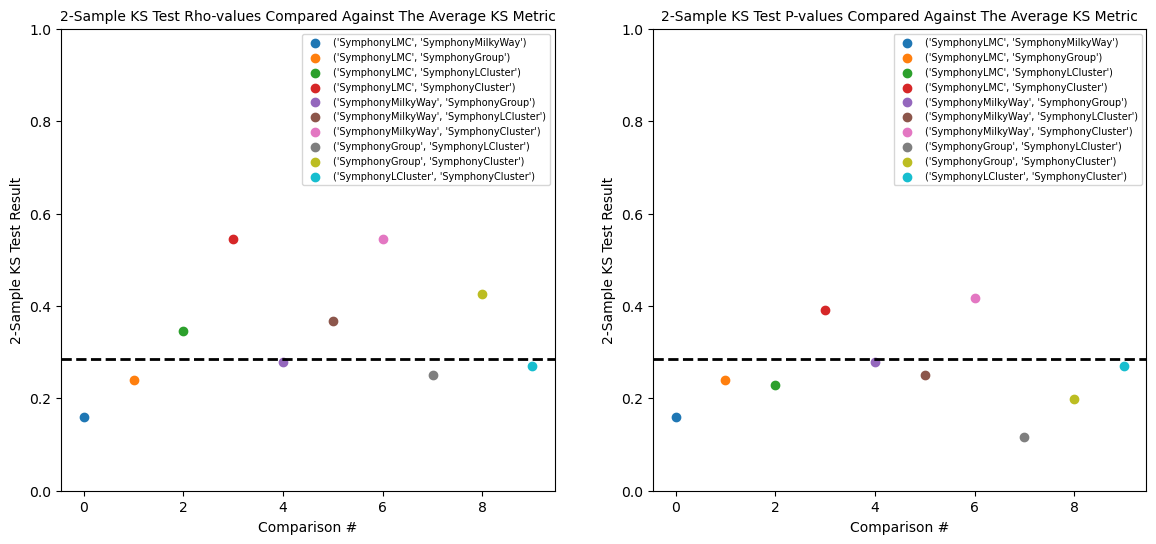

In [99]:
from matplotlib import colormaps
rho_2sampks_results = []
p_2sampks_results = []
suite_list = ["SymphonyLMC", "SymphonyMilkyWay", "SymphonyGroup", "SymphonyLCluster", "SymphonyCluster"]
colors = matplotlib.colormaps['tab10']

fig, axs = plt.subplots(1, 2, figsize = (14,6))
testax = np.arange(0, 10, 1)

r = 2
all_rho_suite_combos = list(combinations(rho_all_suites, r))
all_p_suite_combos = list(combinations(p_all_suites, r))
labels = list(combinations(suite_list, r))

for trial, ks_combo in enumerate(all_rho_suite_combos):
    rhoresults = scipy.stats.ks_2samp(ks_combo[0], ks_combo[1])
    rho_2sampks_results.append(rhoresults[0])

for trial, p_combo in enumerate(all_p_suite_combos):
    print(labels[trial])
    spearp_results = scipy.stats.ks_2samp(p_combo[0], p_combo[1])
    p_2sampks_results.append(spearp_results[0])

for point_index, point in enumerate(testax):
    axs[0].scatter(point, rho_2sampks_results[point_index], label = labels[point_index])
    axs[1].scatter(point, p_2sampks_results[point_index], label = labels[point_index])

    
axs[0].set_xlabel("Comparison #")
axs[0].set_ylabel("2-Sample KS Test Result")
axs[0].set_title("2-Sample KS Test Rho-values Compared Against The Average KS Metric", fontsize = 10)
axs[0].set_ylim(0, 1)
axs[0].legend(loc = "best", fontsize = 7)
axs[0].axhline(y = avg_ks_metric, color = "black", lw = 2, linestyle = "--", label = avg_ks_metric)

axs[1].set_xlabel("Comparison #")
axs[1].set_ylabel("2-Sample KS Test Result")
axs[1].set_title("2-Sample KS Test P-values Compared Against The Average KS Metric", fontsize = 10)
axs[1].set_ylim(0, 1)
axs[1].legend(loc = "best", fontsize = 7)
axs[1].axhline(y = avg_ks_metric, color = "black", lw = 2, linestyle = "--", label = avg_ks_metric)
plt.show()

GIF created and saved at subhalo_animation.gif


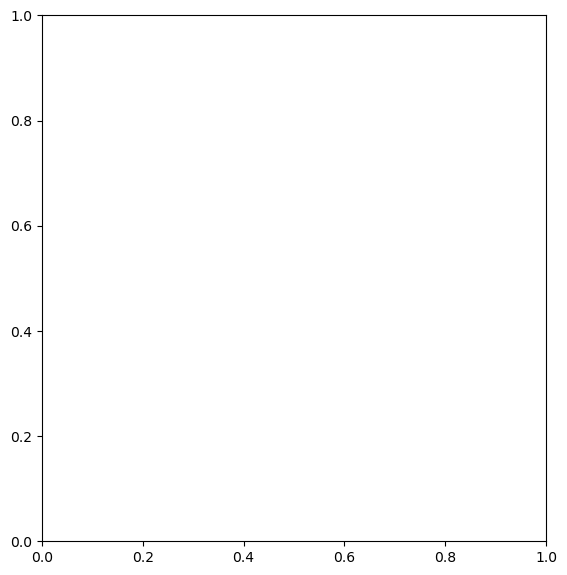

In [2]:
# generating subhalo location and mass vs time gifs!

from matplotlib.animation import FuncAnimation, PillowWriter
from PIL import Image, ImageSequence
import glob
import re

base_dir = "D:/MWest_data"
suite_list = ["SymphonyCluster"]
image_directory = "subhalo_gif/*.png"
output_gif_path = "subhalo_animation.gif"

fig, ax = plt.subplots(ncols = 1, nrows = 1, figsize = (6, 6))

for suite_index, suite_name in enumerate(suite_list):
    n_hosts = symlib.n_hosts(suite_name)
    
    for i_host in range(1):
        sim_dir = symlib.get_host_directory(base_dir, suite_name, i_host)        # get directory to host
        scale_factors = symlib.scale_factors(sim_dir)      # read in scale factors list
        h, hist = symlib.read_subhalos(sim_dir)       # read in data

        redshifts = np.linspace(2, 0, len(scale_factors))

        for i_z, target_z in enumerate(redshifts):
            target_a = 1 / (1 + target_z)                    # convert from target redshift to corresponding scale factor or snapshot
            snap_index = np.argmin(np.abs(scale_factors - target_a))   # round to closest snapshot
            end_snap = np.argmin(np.abs(scale_factors - (1/(1+redshifts[-1]))))   # get the snapshot corresponding to the lowest redshift
        
            host = h[0, snap_index]                            # first halo, last snapshot
            symlib.plot_circle(ax, host["x"][0], host["x"][1], host["rvir"], c = "tab:red")
            #print(sim_dir, target_z, end_snap, len(redshifts))

            z0_radius = 100
        
            for i in range(1, len(h)):
                sub = h[i, snap_index]    # i-th subhalo, last snapshot
                if sub["ok"]:
                    symlib.plot_circle(ax, sub['x'][0], sub['x'][1], sub['rvir'], c = "tab:blue", lw = 1.5)

            ax.set_xlim(-7*host["rvir"], 7*host["rvir"])
            ax.set_ylim(-7*host["rvir"], 7*host["rvir"])
                                        
            #ax.set_xlim(-1000, 1000)
            #ax.set_ylim(-1000, 1000)
            ax.set_title(f'z = {target_z}')
            plt.tight_layout()
            
            output_directory = "subhalo_gif"
            filename = f"subhalo_image_{i_z}.png"
            
            if not os.path.exists(output_directory):
                os.makedirs(output_directory)
                
            full_path = os.path.join(output_directory, filename)
            plt.savefig(full_path, dpi = 150, facecolor = 'white')

            if i_z < len(redshifts): # Clear unless it's the last iteration
                #print(i_z+1, len(redshifts))
                ax.clear()
     

#image_paths = glob.glob(image_directory)
image_paths = sorted(glob.glob(image_directory), key=lambda x: int(re.search(r"(\d+)", x).group()))
 
# Load images 
images = []
for path in image_paths:
    img = Image.open(path)
    images.append(img)

if images:
    images[0].save(output_gif_path, save_all=True, append_images=images[1:], duration = 75, loop=0)
    print(f"GIF created and saved at {output_gif_path}")
else:
    print("No images found in the specified directory.")


#axs[i_z].set_xlim(-1.75*host["rvir"], 1.75*host["rvir"])
#axs[i_z].set_ylim(-1.75*host["rvir"], 1.75*host["rvir"])

1 SymphonyLMC
D:/MWest_data\SymphonyLMC\Halo032
All Objects Populated!
360
Saved!
365
Saved!
370
Saved!
375
Saved!
380
Saved!
385
Saved!
390
Saved!
395
Saved!
400
Saved!
405
Saved!
410
Saved!
415
Saved!
420
Saved!
425
Saved!
430
Saved!
435
Saved!
440
Saved!
445
Saved!


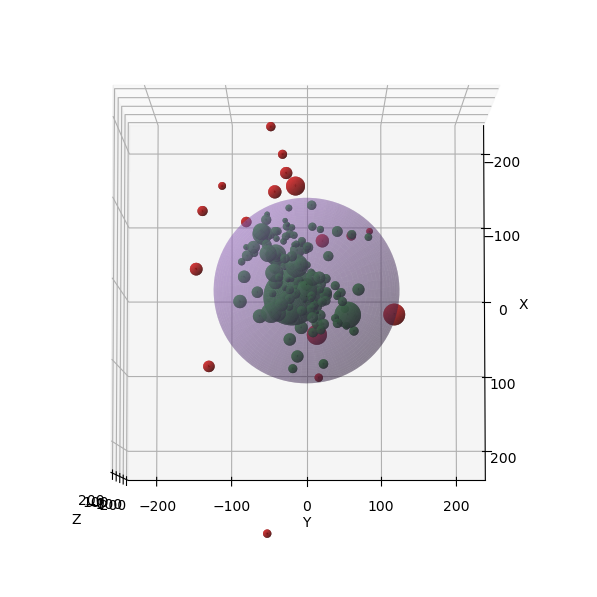

In [89]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.animation as animation

# proof of concept:
base_dir = "D:/MWest_data"
suite_list = ["SymphonyLMC"]
colors = ["tab:purple", "tab:blue", "tab:green", "tab:orange", "tab:red"]
image_directory = "sub_visual_2/*.png"
output_directory = "sub_visual_2"
output_gif_path = "sub_visual_2.gif"

fig = plt.figure(figsize = (7.5, 7.5))
ax = fig.add_subplot(111, projection='3d')

for suiteindex, suite in enumerate(suite_list):
    print(suiteindex + 1, suite)
    
    n_hosts = symlib.n_hosts(suite)

    for i_host in range(1):
        sim_dir = symlib.get_host_directory(base_dir, suite, i_host)
        h, hist = symlib.read_subhalos(sim_dir)
        scale_factors = symlib.scale_factors(sim_dir)

        print(sim_dir)

        host_rvir = h["rvir"][0, -1]
        host_pos = h["x"][0, -1]            # simulation centers around host, so this should be (0, 0, 0)
        sub_rvir = h["rvir"][:, -1]
        sub_pos = h["x"][:, -1]
        ok1 = h["ok"][:, -1]
        
        ok_sub_pos = sub_pos[ok1]
        ok_sub_rvir = sub_rvir[ok1]

        d_host2sub = np.sqrt(np.sum(ok_sub_pos**2, axis=1))

        u = np.linspace(0, 2 * np.pi, 100)
        v = np.linspace(0, np.pi, 50)

        for index, subhalo in enumerate(ok_sub_rvir):
            
            if index == 0:
                host_center = (host_pos[0], host_pos[1], host_pos[2])
                host_cx, host_cy, host_cz = host_center
                
                host_x = host_rvir * np.outer(np.cos(u), np.sin(v)) + host_cx
                host_y = host_rvir * np.outer(np.sin(u), np.sin(v)) + host_cy
                host_z = host_rvir * np.outer(np.ones(np.size(u)), np.cos(v)) + host_cz
                
                #symlib.plot_circle(ax, host_pos[0], host_pos[1], host_pos[2], host_rvir, c = colors[suiteindex], lw = 1.5)
                ax.plot_surface(host_x, host_y, host_z, color = "tab:purple", alpha = 0.333)

            elif index != 0:
                if (d_host2sub[index] < host_rvir - ok_sub_rvir[index]):
                    #symlib.plot_circle(ax, ok_sub_pos[index][0], ok_sub_pos[index][1], ok_sub_rvir[index], c = "tab:green", lw = 1)
                    #symlib.plot_circle(ax, ok_sub_pos[index][0], ok_sub_pos[index][1], 0.1, c = "black", lw = 1)
                    #indexes_in_out["Inside"].append(index)

                    sub_center = (ok_sub_pos[index][0], ok_sub_pos[index][1], ok_sub_pos[index][2])
                    sub_cx, sub_cy, sub_cz = sub_center
                    
                    sub_x = ok_sub_rvir[index] * np.outer(np.cos(u), np.sin(v)) + sub_cx
                    sub_y = ok_sub_rvir[index] * np.outer(np.sin(u), np.sin(v)) + sub_cy
                    sub_z = ok_sub_rvir[index] * np.outer(np.ones(np.size(u)), np.cos(v)) + sub_cz
                    ax.plot_surface(sub_x, sub_y, sub_z, color = "tab:green")
                    

                elif (d_host2sub[index] > host_rvir + ok_sub_rvir[index]):
                #    symlib.plot_circle(ax, ok_sub_pos[index][0], ok_sub_pos[index][1], ok_sub_rvir[index], c = "tab:red", lw = 1)
                #    symlib.plot_circle(ax, ok_sub_pos[index][0], ok_sub_pos[index][1], 0.1, c = "black", lw = 1)
                #    indexes_in_out["Outside"].append(index)

                    sub_center = (ok_sub_pos[index][0], ok_sub_pos[index][1], ok_sub_pos[index][2])
                    sub_cx, sub_cy, sub_cz = sub_center
                    
                    sub_x = ok_sub_rvir[index] * np.outer(np.cos(u), np.sin(v)) + sub_cx
                    sub_y = ok_sub_rvir[index] * np.outer(np.sin(u), np.sin(v)) + sub_cy
                    sub_z = ok_sub_rvir[index] * np.outer(np.ones(np.size(u)), np.cos(v)) + sub_cz
                    ax.plot_surface(sub_x, sub_y, sub_z, color = "tab:red")
        
    ax.set_xlim(-2 * host_rvir, 2 * host_rvir)
    ax.set_ylim(-2 * host_rvir, 2 * host_rvir)
    ax.set_zlim(-2 * host_rvir, 2 * host_rvir)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')

    print("All Objects Populated!")
    
    ax.view_init(elev = 0, azim = 0)

    for angle in range(0, 90, 5):
        print(360 + angle)
        ax.view_init(elev = angle, azim = 360)
        filename = f"Rotation{360 + angle}.png" 
        full_path = os.path.join(output_directory, filename)
        plt.savefig(full_path, dpi = 100, facecolor = 'white')
        print("Saved!")

In [ ]:
pop_image_paths = sorted(glob.glob(image_directory), key=lambda x: int(re.search(r"(\d+)", x).group()))
 
# Load images 
images = []
for path in pop_image_paths:
    img = Image.open(path)
    images.append(img)

if images:
    images[0].save(output_gif_path, save_all=True, append_images=images[1:], duration = 100, loop=0)
    print(f"GIF created and saved at {output_gif_path}")
else:
    print("No images found in the specified directory.")

1 SymphonyLMC
2 SymphonyMilkyWay
3 SymphonyGroup
4 SymphonyLCluster
5 SymphonyCluster


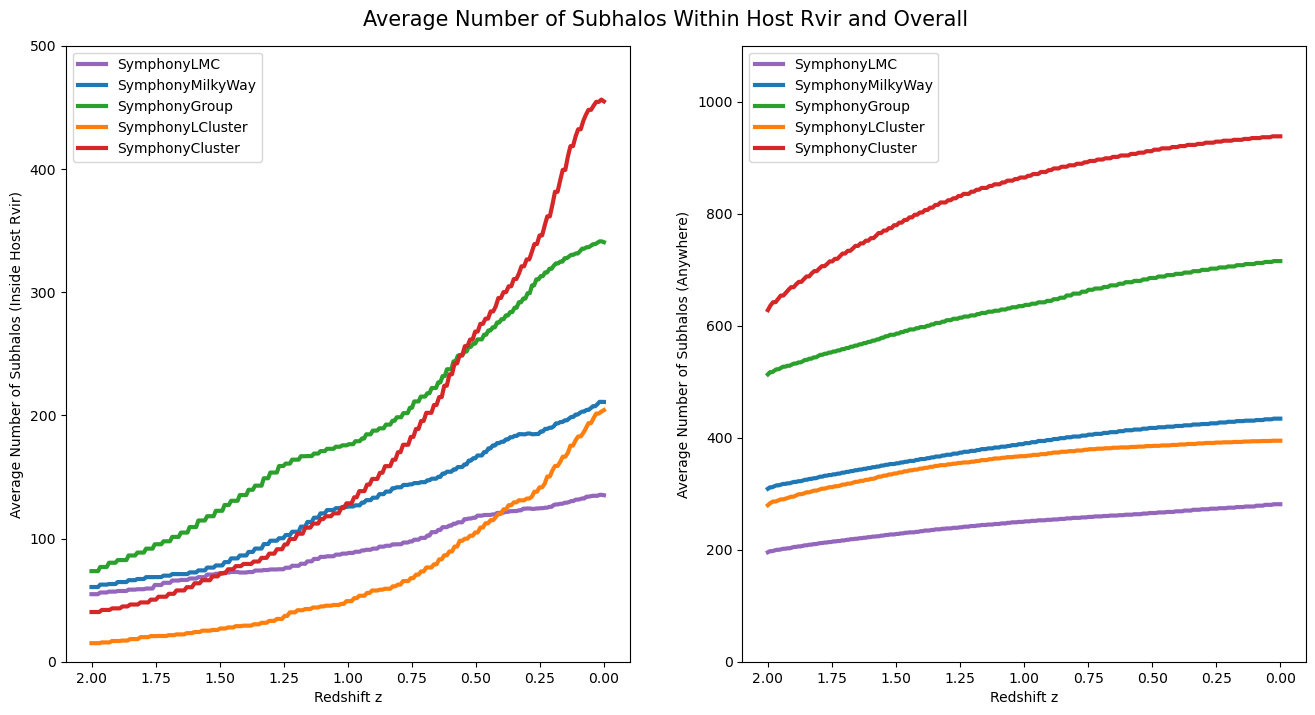

In [82]:
# attempting to make a "subhalo destruction rate" curve
## going to try to keep track of the number of subhalos that exist at z = 2, then see what fraction of those same subhalos exist at z = 0

base_dir = "D:/MWest_data"
#suite_list = ["SymphonyLMC"]
suite_list = ["SymphonyLMC", "SymphonyMilkyWay", "SymphonyGroup", "SymphonyLCluster", "SymphonyCluster"]
og_colors = ["tab:purple", "tab:blue", "tab:green", "tab:orange", "tab:red"]

# figure setup
fig, ax = plt.subplots(ncols = 2, nrows = 1, figsize = (16, 8))

for suite_index, suite in enumerate(suite_list):

    print(suite_index + 1, suite)

    n_hosts = symlib.n_hosts(suite)

    suite_num_subhalos = []
    suite_all_subhalos = []

    for host_index in range(n_hosts):
        sim_dir = symlib.get_host_directory(base_dir, suite, host_index)
        scale_factors = symlib.scale_factors(sim_dir)
        h, hist = symlib.read_subhalos(sim_dir)

        redshifts = np.linspace(0, 2, len(scale_factors))
        num_subhalos = np.zeros(len(scale_factors))
        all_subhalos1 = np.zeros(len(scale_factors))

        for z_index, target_z in enumerate(redshifts):
            target_a = 1 / (1 + target_z)
            snap_index = np.argmin(np.abs(scale_factors - target_a))
            end_snap = np.argmin(np.abs(scale_factors - (1/(1+redshifts[-1]))))

            host_rvir = h["rvir"][0, snap_index]
            host_pos = h["x"][0, snap_index]

            # filter out subhalos that aren't the host and are still alive at the snapshot
            sub_rvir = h["rvir"][1:, snap_index]
            sub_pos = h["x"][1:, snap_index]
            
            ok1 = h["ok"][1:, snap_index]
            ok_sub_pos = sub_pos[ok1]
            ok_sub_rvir = sub_rvir[ok1]

            dist = np.sqrt(np.sum(ok_sub_pos**2, axis=1))

            arr_host_rvir = host_rvir * np.ones(len(dist))
            sub_exists_inside_hostrvir = (dist < arr_host_rvir - ok_sub_rvir)
            sub_exists = ok1
            num_subhalos[z_index] = sum(sub_exists_inside_hostrvir)             # total number of subhalos inside the host virial radius
            all_subhalos1[z_index] = sum(sub_exists)
            all_subhalos2 = all_subhalos1[::-1]


        suite_num_subhalos.append(num_subhalos)
        suite_all_subhalos.append(all_subhalos2)

    tot_suite_num_subs = (np.sum(np.array(suite_num_subhalos), axis = 0))
    tot_suite_all_subs = (np.sum(np.array(suite_all_subhalos), axis = 0))

    ax[0].plot(redshifts, tot_suite_num_subs / n_hosts, color = og_colors[suite_index], lw = 3, label = suite)
    ax[0].legend(loc = "best", fontsize = 10)
    ax[0].set_xlabel("Redshift z", fontsize = 10)
    ax[0].set_ylabel("Average Number of Subhalos (Inside Host Rvir)")
    ax[0].set_xlim(2.1, -0.1)
    ax[0].set_ylim(0, 500)
    
    ax[1].plot(redshifts, tot_suite_all_subs / n_hosts, color = og_colors[suite_index], lw = 3, label = suite)
    ax[1].legend(loc = "best", fontsize = 10)
    ax[1].set_xlabel("Redshift z", fontsize = 10)
    ax[1].set_ylabel("Average Number of Subhalos (Anywhere)")
    ax[1].set_xlim(2.1, -0.1)
    ax[1].set_ylim(0, 1100)

fig.suptitle("Average Number of Subhalos Within Host Rvir and Overall", y = 0.925, fontsize = 15)
plt.show()